In [1]:
#Seaborn: Advanced Visualization to make it more appealing
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
#Install and import Seaborn

import seaborn as sns

# Only get data analyst jobs in the US and dropping NA values from yearly salary column
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])



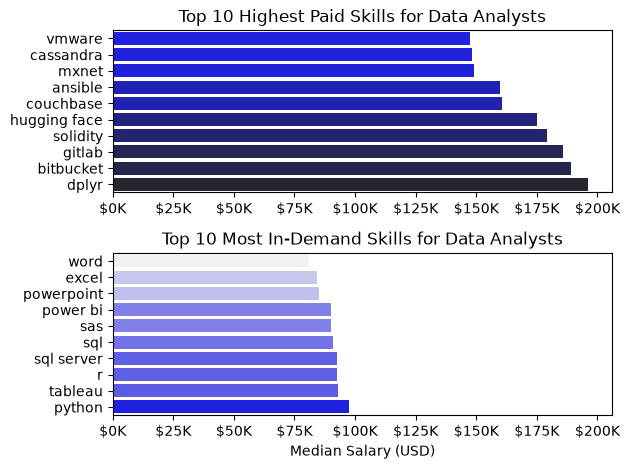

In [ ]:
#Using the dataset from the exercise in Matplot_Stats
df_DA_US = df[(df['job_title_short'] =='Data Analyst') & (df['job_country'] == 'United States')].copy().dropna(subset = 'salary_year_avg')
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US[['salary_year_avg','job_skills']]
df_DA_US_grouped = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_DA_top_pay = df_DA_US_grouped.sort_values(by = 'median',ascending = False).head(10)
df_DA_skills = df_DA_US_grouped.sort_values(by = 'count',ascending=False).head(10).sort_values(by = 'median',ascending = False)


<function matplotlib.pyplot.show(close=None, block=None)>

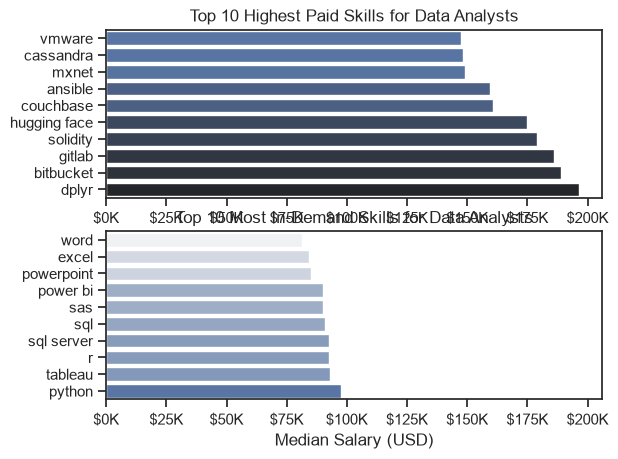

In [ ]:
# For bar chart in seaborn

fig, ax = plt.subplots(2,1)

sns.set_theme(style = 'ticks')                                                                                          #Sets a overall theme

            #df_DA_top_pay.plot(kind = 'barh', y = 'median', ax = ax[0],legend = False)
sns.barplot(data = df_DA_top_pay, x = 'median', y = df_DA_top_pay.index, ax = ax[0], hue = 'median', palette = 'dark:b_r')        #The only difference is adding this line here
ax[0].legend().remove()                                                                                                               #Adding the _r reverses the color order
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


            #df_DA_skills.plot(kind = 'barh', y = 'median', ax = ax[1],legend = False)
sns.barplot(data = df_DA_skills, x = 'median', y = df_DA_skills.index, ax = ax[1],hue = 'median',palette = 'light:b')              #The only difference is adding this line here
ax[1].legend().remove()      #remove the legend
ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())          
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout
plt.show

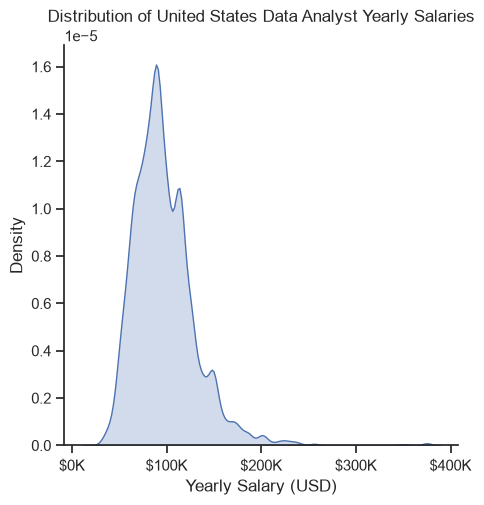

In [ ]:
# For histogram in seaborn
#Dis plot makes more smoother curves on the histogram instead of histplot
#df_DA_US['salary_year_avg'].plot(kind = 'hist', bins = 30, edgecolor = 'black')

sns.displot(df_DA_US['salary_year_avg'], kind = 'kde', fill = True)                               #This line. data is taken from the column. kde is Kernal Density Estimation, so it makes a more smoother curve.

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Density') 
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

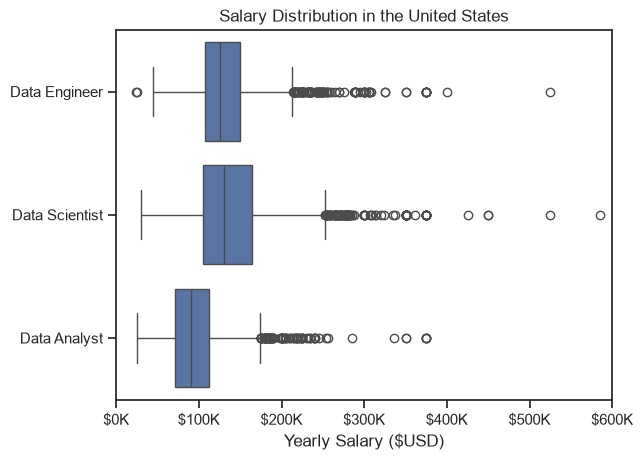

In [24]:
# For boxplot in seaborn
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy() 
df_US = df_US.dropna(subset= ['salary_year_avg'])
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]      
     

sns.boxplot(data = df_US, x = 'salary_year_avg', y = 'job_title_short')                                       #This line
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
ax =plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.xlim(0,600000)
plt.show()   



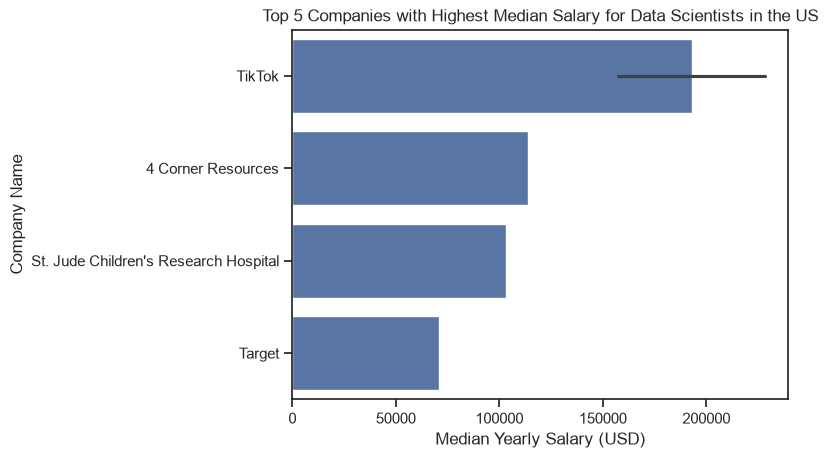

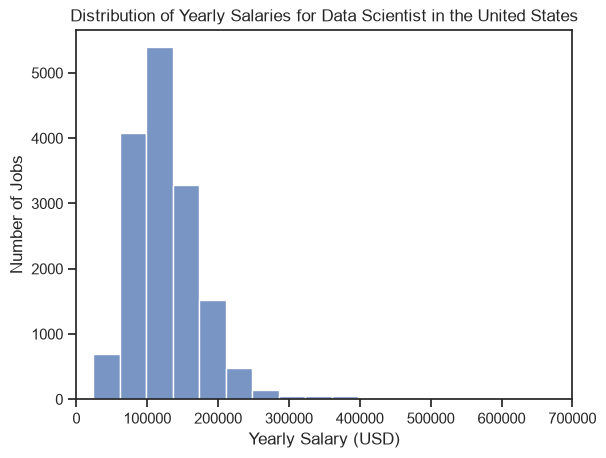

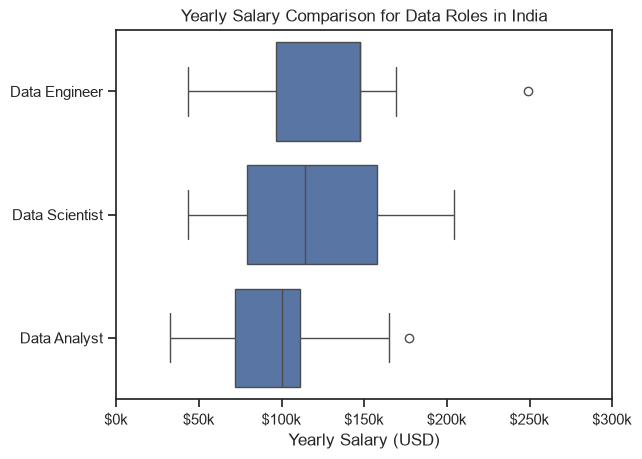

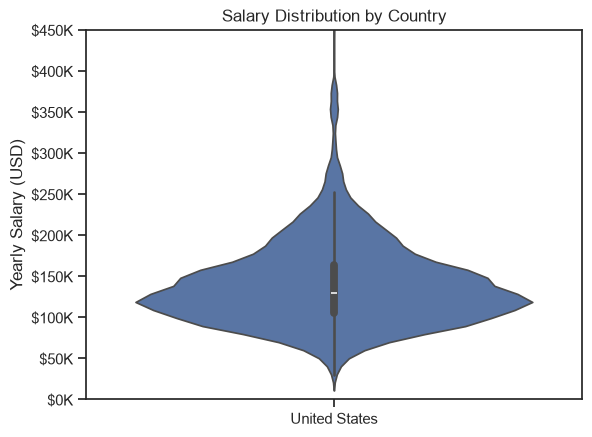

In [36]:
# PRACTICE PROBLEMS
df_DA_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg']).head(5)
top_companies = df_DA_US.groupby('company_name')['salary_year_avg'].median().nlargest(5).reset_index()
sns.barplot(data = df_DA_US, x = 'salary_year_avg', y = 'company_name')
plt.title('Top 5 Companies with Highest Median Salary for Data Scientists in the US')
plt.xlabel('Median Yearly Salary (USD)')
plt.ylabel('Company Name')
plt.show()

df_US = df[df['job_country'] == 'United States']
df_US = df_US.dropna(subset='salary_year_avg')
sns.histplot(df_US['salary_year_avg'],bins = 25, kde = False)
plt.xlabel('Yearly Salary (USD)')
plt.title('Distribution of Yearly Salaries for Data Scientist in the United States')
plt.ylabel('Number of Jobs')
plt.xlim(0,700000)
plt.show()

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_India = df[(df['job_country'] == 'India') & (df['job_title_short'].isin(job_titles))]
df_India = df_India.dropna(subset=['salary_year_avg'])
sns.boxplot(data = df_India, x = 'salary_year_avg', y ='job_title_short')
plt.title('Yearly Salary Comparison for Data Roles in India')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 300000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.show()

df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])
sns.violinplot(x='job_country', y='salary_year_avg', data=df_DS_US)
plt.title('Salary Distribution by Country')
plt.xlabel('')
plt.ylabel('Yearly Salary (USD)')
plt.ylim(0, 450000)  
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()